# Phase 5: Co-Training & Evaluation

Outline:
- 5.1 Imports & load models
- 5.2 Co-training loop (Cleaner → Router → reward → update)
- 5.3 Co-training results & curves
- 5.4 A* baseline evaluation
- 5.5 RL vs A* comparison table
- 5.6 Ablation: Router without MCTS
- 5.7 Final summary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from copy import deepcopy
from typing import List, Tuple, Optional, Dict
from routing_env import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

gymnasium available
NumPy: 2.2.6
All imports OK
Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)
Device: cuda


In [2]:
# Strict overlap helper
def compute_overlaps_strict(state, nets):
    pin_cells = {cell for src, snk in nets for cell in (src, snk)}
    congestion = state[C_CONGESTION]
    return sum(
        1 for r in range(GRID_SIZE) for c in range(GRID_SIZE)
        if congestion[r, c] > 1 and (r, c) not in pin_cells
    )

# Load working configs (real mid-path overlaps)
all_configs_m2 = generate_net_configs(min_manhattan=2, seed=42)
all_configs = []
for cfg in all_configs_m2:
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)
    if compute_overlaps_strict(state, nets) > 0:
        all_configs.append(cfg)

# Train / val / test split
np.random.seed(42)
idx       = np.random.permutation(len(all_configs))
n_train   = int(0.7 * len(idx))
n_val     = int(0.15 * len(idx))
train_cfgs = [all_configs[i] for i in idx[:n_train]]
val_cfgs   = [all_configs[i] for i in idx[n_train:n_train+n_val]]
test_cfgs  = [all_configs[i] for i in idx[n_train+n_val:]]

print(f'Total configs : {len(all_configs)}')
print(f'Train         : {len(train_cfgs)}')
print(f'Val           : {len(val_cfgs)}')
print(f'Test          : {len(test_cfgs)}')

Total configs : 5000
Train         : 3500
Val           : 750
Test          : 750


In [3]:
# Model definitions
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class CleanerCNN(nn.Module):
    def __init__(self, in_channels=NUM_CHANNELS, num_classes=NUM_NETS):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            ConvBlock(in_channels, 16), ConvBlock(16, 32),
            ConvBlock(32, 64),          ConvBlock(64, 128),
        )
        flat = 128 * GRID_SIZE * GRID_SIZE
        self.dense_blocks = nn.Sequential(
            nn.Linear(flat, 512), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.conv_blocks(x)
        return self.dense_blocks(x.view(x.size(0), -1))
    def predict_net(self, state_np):
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            return self(x).argmax(dim=1).item()

class RouterCNN(nn.Module):
    def __init__(self, in_channels=NUM_CHANNELS, num_actions=4):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(in_channels, 16), ConvBlock(16, 32),
            ConvBlock(32, 64),          ConvBlock(64, 128),
        )
        flat = 128 * GRID_SIZE * GRID_SIZE
        self.policy_head = nn.Sequential(
            nn.Linear(flat, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.3),      nn.Linear(512, num_actions)
        )
        self.value_head = nn.Sequential(
            nn.Linear(flat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),      nn.Linear(256, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.backbone(x).view(x.size(0), -1)
        return self.policy_head(x), self.value_head(x)
    def predict(self, state_np):
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            p, v = self(x)
            return F.softmax(p, dim=1).cpu().numpy()[0], v.cpu().numpy()[0, 0]

# Load pretrained weights
cleaner_model = CleanerCNN().to(device)
cleaner_model.load_state_dict(
    torch.load('checkpoints/cleaner_best.pt', map_location=device))

router_model = RouterCNN().to(device)
router_model.load_state_dict(
    torch.load('checkpoints/router_best.pt', map_location=device))

print('Cleaner loaded')
print('Router  loaded')

Cleaner loaded
Router  loaded


In [4]:
# Routing helpers
def greedy_route(model, nets, partial_paths, net_idx):
    src, snk = nets[net_idx]
    blocked  = set()
    for i, p in enumerate(partial_paths):
        if p and i != net_idx:
            for cell in p: blocked.add(cell)
    blocked.discard(src); blocked.discard(snk)

    current, path, visited = src, [src], {src}
    for _ in range(GRID_SIZE * GRID_SIZE):
        if current == snk: return path
        temp         = deepcopy(partial_paths)
        temp[net_idx] = path
        cur_state    = build_state_tensor(nets, temp, GRID_SIZE)
        valid        = [
            a for a, (dr, dc) in ACTIONS.items()
            if 0 <= current[0]+dr < GRID_SIZE
            and 0 <= current[1]+dc < GRID_SIZE
            and (current[0]+dr, current[1]+dc) not in blocked
            and (current[0]+dr, current[1]+dc) not in visited
        ]
        if not valid: break
        probs, _ = model.predict(cur_state)
        a        = max(valid, key=lambda x: probs[x])
        nxt      = (current[0]+ACTIONS[a][0], current[1]+ACTIONS[a][1])
        path.append(nxt); visited.add(nxt); current = nxt
    return astar(GRID_SIZE, src, snk, blocked=blocked)  # A* fallback


def run_pipeline(cleaner, router, nets, paths, rounds=3):
    """Run Cleaner->Router pipeline. Returns (final_paths, overlaps, wirelength)."""
    rl_paths = deepcopy(paths)
    for _ in range(rounds):
        state = build_state_tensor(nets, rl_paths, GRID_SIZE)
        if compute_overlaps_strict(state, nets) == 0:
            break
        net_rem          = cleaner.predict_net(state)
        rl_paths[net_rem] = None
        new_path         = greedy_route(router, nets, rl_paths, net_rem)
        if new_path:
            rl_paths[net_rem] = new_path
    state = build_state_tensor(nets, rl_paths, GRID_SIZE)
    ov    = compute_overlaps_strict(state, nets)
    wl    = compute_total_wirelength(rl_paths) if all(rl_paths) else None
    return rl_paths, ov, wl


print('Helpers ready')

Helpers ready


## 5.2: Co-Training Loop

In [5]:
# Co-training hyperparameters
CO_EPOCHS      = 30
CO_LR          = 1e-4       # fine-tuning LR (lower than initial)
CO_BATCH       = 32
CO_PATIENCE    = 10
ROUNDS         = 3          # Cleaner->Router rounds per config

cleaner_opt = optim.Adam(cleaner_model.parameters(), lr=CO_LR, weight_decay=1e-4)
router_opt  = optim.Adam(router_model.parameters(),  lr=CO_LR, weight_decay=1e-4)
ce_loss     = nn.CrossEntropyLoss()
mse_loss    = nn.MSELoss()

co_history = {
    'epoch': [], 'train_completion': [], 'val_completion': [],
    'train_wirelength': [], 'val_wirelength': [],
    'cleaner_loss': [], 'router_loss': []
}

best_val_completion = 0.0
patience_count      = 0
os.makedirs('checkpoints', exist_ok=True)

print(f'Co-training for {CO_EPOCHS} epochs')
print(f'  Train configs : {len(train_cfgs)}')
print(f'  Val configs   : {len(val_cfgs)}')
print(f'  LR            : {CO_LR}')
print(f'  Patience      : {CO_PATIENCE}')

Co-training for 30 epochs
  Train configs : 3500
  Val configs   : 750
  LR            : 0.0001
  Patience      : 10


In [6]:
def co_train_epoch(configs):
    """
    One co-training epoch:
      1. Run pipeline on each config
      2. If success  → reinforce Cleaner choice + Router path
      3. If failure  → penalise Cleaner choice, supervise Router with A* path
    Returns (completion_rate, avg_wirelength, cleaner_loss, router_loss)
    """
    cleaner_model.train(); router_model.train()
    completed, total = 0, 0
    wirelengths      = []
    c_losses, r_losses = [], []

    np.random.shuffle(configs)

    for cfg in configs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)

        if compute_overlaps_strict(state, nets) == 0:
            continue
        total += 1

        # ── Run pipeline ──────────────────────────────────────────────────
        rl_paths = deepcopy(paths)
        episode  = []  # (state, net_chosen, success)

        for _ in range(ROUNDS):
            cur_state = build_state_tensor(nets, rl_paths, GRID_SIZE)
            if compute_overlaps_strict(cur_state, nets) == 0:
                break
            net_rem = cleaner_model.predict_net(cur_state)
            rl_paths[net_rem] = None
            new_path = greedy_route(router_model, nets, rl_paths, net_rem)
            if new_path:
                rl_paths[net_rem] = new_path
            episode.append((cur_state, net_rem))

        final_state = build_state_tensor(nets, rl_paths, GRID_SIZE)
        success     = compute_overlaps_strict(final_state, nets) == 0 and all(rl_paths)

        if success:
            completed += 1
            wirelengths.append(compute_total_wirelength(rl_paths))

        # ── Cleaner update ────────────────────────────────────────────────
        if episode:
            ep_state, ep_net = episode[0]  # first decision
            x_c = torch.tensor(ep_state, dtype=torch.float32).unsqueeze(0).to(device)

            if success:
                # Reinforce: label = net that was chosen (it worked)
                target_c = torch.tensor([ep_net], dtype=torch.long).to(device)
            else:
                # Penalise: find net that A* can fix, use as label
                pin_cells = {cell for s, k in nets for cell in (s, k)}
                correct_net = None
                for n in range(NUM_NETS):
                    tp = deepcopy(paths); tp[n] = None
                    bl = set(c for i,p in enumerate(tp) if p and i!=n for c in p)
                    s0, k0 = nets[n]; bl.discard(s0); bl.discard(k0)
                    np_ = astar(GRID_SIZE, s0, k0, blocked=bl)
                    if np_:
                        tp[n] = np_
                        ts = build_state_tensor(nets, tp, GRID_SIZE)
                        if compute_overlaps_strict(ts, nets) == 0:
                            correct_net = n; break
                if correct_net is None:
                    correct_net = ep_net  # no better option known
                target_c = torch.tensor([correct_net], dtype=torch.long).to(device)

            cleaner_model.train()
            cleaner_opt.zero_grad()
            logits_c = cleaner_model(x_c)
            loss_c   = ce_loss(logits_c, target_c)
            loss_c.backward()
            cleaner_opt.step()
            c_losses.append(loss_c.item())

        # Router update 
        # Supervise Router with A* path for the net the Cleaner chose
        if episode:
            ep_state, ep_net = episode[0]
            partial = deepcopy(paths); partial[ep_net] = None
            blocked = set(c for i,p in enumerate(partial) if p and i!=ep_net for c in p)
            s0, k0  = nets[ep_net]; blocked.discard(s0); blocked.discard(k0)
            astar_p = astar(GRID_SIZE, s0, k0, blocked=blocked)

            if astar_p and len(astar_p) > 1:
                # First action of A* path as supervision
                dr = astar_p[1][0] - astar_p[0][0]
                dc = astar_p[1][1] - astar_p[0][1]
                action_map = {(-1,0):0,(1,0):1,(0,-1):2,(0,1):3}
                target_a   = action_map.get((dr, dc), 0)

                x_r      = torch.tensor(ep_state, dtype=torch.float32).unsqueeze(0).to(device)
                target_r = torch.tensor([target_a], dtype=torch.long).to(device)
                reward_v = torch.tensor([1.0 if success else -1.0],
                                        dtype=torch.float32).to(device)

                router_model.train()
                router_opt.zero_grad()
                p_logits, v_pred = router_model(x_r)
                loss_r = ce_loss(p_logits, target_r) + 0.5 * mse_loss(v_pred.squeeze(), reward_v)
                loss_r.backward()
                router_opt.step()
                r_losses.append(loss_r.item())

    comp_rate = completed / total if total > 0 else 0.0
    avg_wl    = float(np.mean(wirelengths)) if wirelengths else None
    avg_cl    = float(np.mean(c_losses))    if c_losses    else 0.0
    avg_rl    = float(np.mean(r_losses))    if r_losses    else 0.0
    return comp_rate, avg_wl, avg_cl, avg_rl


def evaluate_configs(configs, cleaner, router):
    """Evaluate completion rate and wirelength on a set of configs."""
    cleaner.eval(); router.eval()
    completed, total, wirelengths = 0, 0, []
    for cfg in configs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)
        if compute_overlaps_strict(state, nets) == 0:
            continue
        total += 1
        _, ov, wl = run_pipeline(cleaner, router, nets, paths)
        if ov == 0 and wl is not None:
            completed += 1
            wirelengths.append(wl)
    rate = completed / total if total > 0 else 0.0
    return rate, float(np.mean(wirelengths)) if wirelengths else None, total


print('Co-training functions ready')

Co-training functions ready


In [7]:
print(f'Starting co-training for {CO_EPOCHS} epochs...')
print(f'{"Epoch":>6} {"Train Comp":>11} {"Val Comp":>10} '
      f'{"Train WL":>10} {"Val WL":>8} {"C-Loss":>8} {"R-Loss":>8}')
print('-' * 70)

for epoch in range(1, CO_EPOCHS + 1):
    t_comp, t_wl, c_loss, r_loss = co_train_epoch(list(train_cfgs))
    v_comp, v_wl, v_total        = evaluate_configs(val_cfgs, cleaner_model, router_model)

    co_history['epoch'].append(epoch)
    co_history['train_completion'].append(t_comp)
    co_history['val_completion'].append(v_comp)
    co_history['train_wirelength'].append(t_wl or 0)
    co_history['val_wirelength'].append(v_wl or 0)
    co_history['cleaner_loss'].append(c_loss)
    co_history['router_loss'].append(r_loss)

    t_wl_str = f'{t_wl:.2f}' if t_wl else '  N/A'
    v_wl_str = f'{v_wl:.2f}' if v_wl else '  N/A'
    flag     = ''

    if v_comp > best_val_completion:
        best_val_completion = v_comp
        patience_count      = 0
        torch.save(cleaner_model.state_dict(), 'checkpoints/co_cleaner_best.pt')
        torch.save(router_model.state_dict(),  'checkpoints/co_router_best.pt')
        flag = ' <- best'
    else:
        patience_count += 1

    print(f'{epoch:>6} {t_comp*100:>10.1f}% {v_comp*100:>9.1f}% '
          f'{t_wl_str:>10} {v_wl_str:>8} '
          f'{c_loss:>8.4f} {r_loss:>8.4f}{flag}')

    if patience_count >= CO_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nCo-training complete. Best val completion: {best_val_completion*100:.1f}%')

Starting co-training for 30 epochs...
 Epoch  Train Comp   Val Comp   Train WL   Val WL   C-Loss   R-Loss
----------------------------------------------------------------------


/scratch/cdse815/fall_2025/gmriechi/COMP841-FinalProject/comp841RL/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


     1       93.3%      93.1%      11.24    11.50   0.0632   0.2146 <- best
     2       93.9%      93.2%      11.34    11.47   0.0213   0.0325 <- best
     3       94.1%      93.2%      11.34    11.47   0.0137   0.0149
     4       94.1%      93.3%      11.42    11.54   0.0136   0.0177 <- best
     5       94.3%      93.2%      11.46    11.49   0.0068   0.0064
     6       94.1%      93.2%      11.37    11.39   0.0110   0.0143
     7       94.2%      93.3%      11.43    11.56   0.0087   0.0064
     8       94.2%      93.2%      11.44    11.36   0.0071   0.0104
     9       94.2%      93.3%      11.36    11.67   0.0028   0.0036
    10       94.2%      93.3%      11.63    11.67   0.0015   0.0002
    11       94.3%      93.3%      11.59    11.42   0.0001   0.0104
    12       94.3%      93.3%      11.47    11.58   0.0002   0.0072
    13       94.2%      93.1%      11.46    11.54   0.0048   0.0128
    14       94.2%      93.3%      11.44    11.44   0.0007   0.0087

Early stopping at epoch

## 5.3: Co-Training Curves

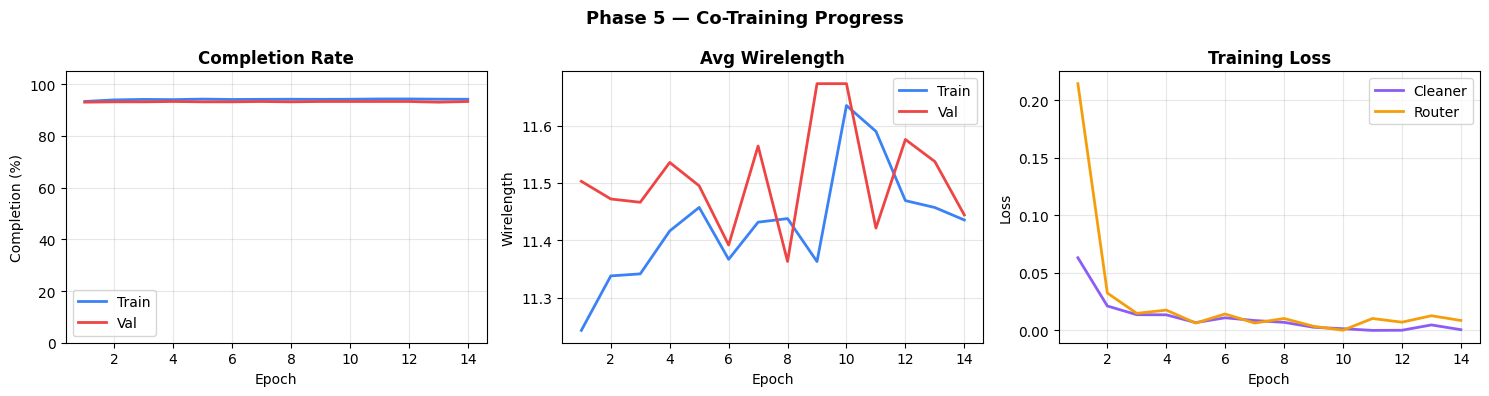

In [8]:
epochs = co_history['epoch']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 5 — Co-Training Progress', fontsize=13, fontweight='bold')

# Completion rate
axes[0].plot(epochs, [x*100 for x in co_history['train_completion']],
             color='#3B82F6', linewidth=2, label='Train')
axes[0].plot(epochs, [x*100 for x in co_history['val_completion']],
             color='#EF4444', linewidth=2, label='Val')
axes[0].set_title('Completion Rate', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Completion (%)')
axes[0].set_ylim(0, 105)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Wirelength
axes[1].plot(epochs, co_history['train_wirelength'],
             color='#3B82F6', linewidth=2, label='Train')
axes[1].plot(epochs, co_history['val_wirelength'],
             color='#EF4444', linewidth=2, label='Val')
axes[1].set_title('Avg Wirelength', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Wirelength')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Losses
axes[2].plot(epochs, co_history['cleaner_loss'],
             color='#8B5CF6', linewidth=2, label='Cleaner')
axes[2].plot(epochs, co_history['router_loss'],
             color='#F59E0B', linewidth=2, label='Router')
axes[2].set_title('Training Loss', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase5_cotraining_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.4: A* Baseline Evaluation

In [9]:
def evaluate_astar(configs):
    """A* baseline: try removing each net, re-route with A*, take best result."""
    completed, total, wirelengths = 0, 0, []
    t0 = time.time()

    for cfg in configs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)
        if compute_overlaps_strict(state, nets) == 0:
            continue
        total += 1

        for net_rem in range(NUM_NETS):
            tp = deepcopy(paths); tp[net_rem] = None
            bl = set(c for i,p in enumerate(tp) if p and i!=net_rem for c in p)
            s0, k0 = nets[net_rem]; bl.discard(s0); bl.discard(k0)
            np_ = astar(GRID_SIZE, s0, k0, blocked=bl)
            if np_:
                tp[net_rem] = np_
                ts = build_state_tensor(nets, tp, GRID_SIZE)
                if compute_overlaps_strict(ts, nets) == 0:
                    completed += 1
                    wirelengths.append(compute_total_wirelength(tp))
                    break

    elapsed = time.time() - t0
    return {
        'completion_rate': completed / total if total > 0 else 0,
        'avg_wirelength':  float(np.mean(wirelengths)) if wirelengths else None,
        'total':           total,
        'runtime_s':       elapsed
    }


print('Evaluating A* on test set...')
astar_results = evaluate_astar(test_cfgs)
print(f'  Configs tested    : {astar_results["total"]}')
print(f'  Completion rate   : {astar_results["completion_rate"]*100:.1f}%')
print(f'  Avg wirelength    : {astar_results["avg_wirelength"]:.2f}')
print(f'  Runtime           : {astar_results["runtime_s"]:.2f}s')

Evaluating A* on test set...
  Configs tested    : 750
  Completion rate   : 94.9%
  Avg wirelength    : 11.55
  Runtime           : 0.10s


## 5.5: RL vs A* Comparison

In [10]:
# Load best co-trained models
cleaner_model.load_state_dict(
    torch.load('checkpoints/co_cleaner_best.pt', map_location=device))
router_model.load_state_dict(
    torch.load('checkpoints/co_router_best.pt', map_location=device))
cleaner_model.eval(); router_model.eval()

print('Evaluating RL pipeline on test set...')
t0 = time.time()
rl_comp, rl_wl, rl_total = evaluate_configs(test_cfgs, cleaner_model, router_model)
rl_time = time.time() - t0

print(f'  Configs tested    : {rl_total}')
print(f'  Completion rate   : {rl_comp*100:.1f}%')
print(f'  Avg wirelength    : {rl_wl:.2f}' if rl_wl else '  Avg wirelength    : N/A')
print(f'  Runtime           : {rl_time:.2f}s')

# Also evaluate pretrained (before co-training) for comparison
cleaner_pre = CleanerCNN().to(device)
cleaner_pre.load_state_dict(
    torch.load('checkpoints/cleaner_best.pt', map_location=device))
router_pre  = RouterCNN().to(device)
router_pre.load_state_dict(
    torch.load('checkpoints/router_best.pt', map_location=device))
cleaner_pre.eval(); router_pre.eval()

pre_comp, pre_wl, _ = evaluate_configs(test_cfgs, cleaner_pre, router_pre)
print(f'\nPre co-training RL  : {pre_comp*100:.1f}%')
print(f'Post co-training RL : {rl_comp*100:.1f}%')
print(f'A* baseline         : {astar_results["completion_rate"]*100:.1f}%')

Evaluating RL pipeline on test set...
  Configs tested    : 750
  Completion rate   : 94.8%
  Avg wirelength    : 11.46
  Runtime           : 2.94s

Pre co-training RL  : 60.9%
Post co-training RL : 94.8%
A* baseline         : 94.9%



  Method                   Completion     Avg WL
  A* Baseline                   94.9%      11.55
  RL (pre co-train)             60.9%      11.51
  RL (post co-train)            94.8%      11.46


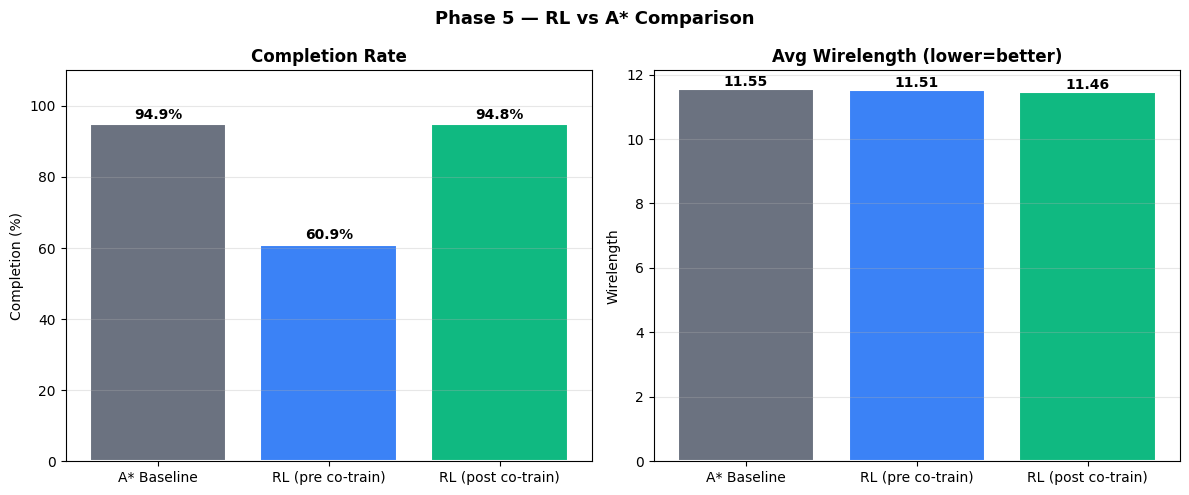

In [11]:
methods = ['A* Baseline', 'RL (pre co-train)', 'RL (post co-train)']
comp    = [
    astar_results['completion_rate']*100,
    pre_comp*100,
    rl_comp*100
]
wl      = [
    astar_results['avg_wirelength'] or 0,
    pre_wl or 0,
    rl_wl  or 0
]

print('\n' + '='*55)
print(f'  {"Method":<22} {"Completion":>12} {"Avg WL":>10}')
print('='*55)
for m, c, w in zip(methods, comp, wl):
    print(f'  {m:<22} {c:>11.1f}% {w:>10.2f}')
print('='*55)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phase 5 — RL vs A* Comparison', fontsize=13, fontweight='bold')
colors = ['#6B7280', '#3B82F6', '#10B981']

axes[0].bar(methods, comp, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Completion Rate', fontweight='bold')
axes[0].set_ylabel('Completion (%)')
axes[0].set_ylim(0, 110)
for i, v in enumerate(comp):
    axes[0].text(i, v+1.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(methods, wl, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Wirelength (lower=better)', fontweight='bold')
axes[1].set_ylabel('Wirelength')
for i, v in enumerate(wl):
    if v > 0:
        axes[1].text(i, v+0.1, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('phase5_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.6: Ablation: Router without MCTS

Running ablation: random Cleaner...
  Random Cleaner completion : 66.4%
  Cleaner CNN completion    : 94.8%
  Delta                     : +28.4%


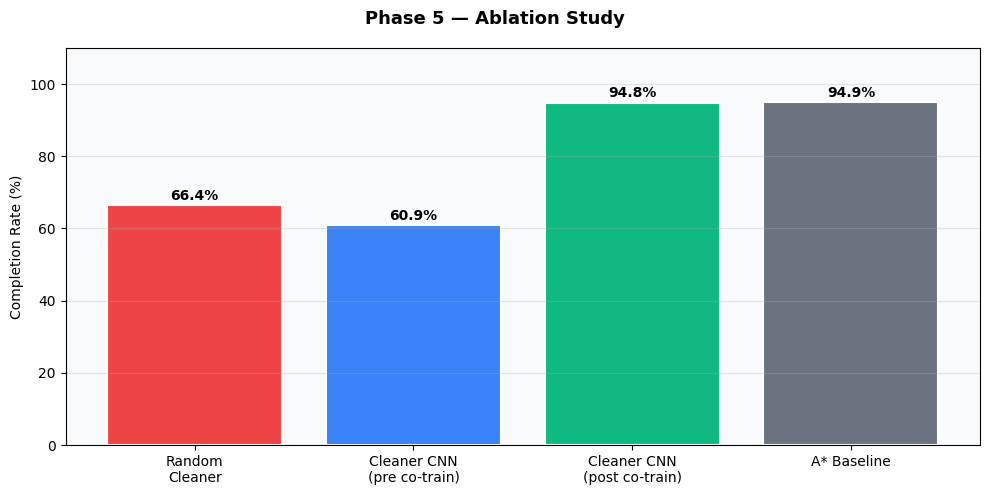

In [12]:
# Greedy-only router (no MCTS) — already what we use.
# Ablation: random net selection instead of Cleaner CNN

def evaluate_random_cleaner(configs, router):
    """Ablation: random net removal instead of Cleaner CNN."""
    completed, total, wirelengths = 0, 0, []
    rng = np.random.default_rng(42)
    for cfg in configs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)
        if compute_overlaps_strict(state, nets) == 0:
            continue
        total += 1
        rl_paths = deepcopy(paths)
        for _ in range(3):
            s = build_state_tensor(nets, rl_paths, GRID_SIZE)
            if compute_overlaps_strict(s, nets) == 0:
                break
            net_rem = int(rng.integers(0, NUM_NETS))
            rl_paths[net_rem] = None
            new_path = greedy_route(router, nets, rl_paths, net_rem)
            if new_path:
                rl_paths[net_rem] = new_path
        s = build_state_tensor(nets, rl_paths, GRID_SIZE)
        if compute_overlaps_strict(s, nets) == 0 and all(rl_paths):
            completed += 1
            wirelengths.append(compute_total_wirelength(rl_paths))
    rate = completed / total if total > 0 else 0
    return rate, float(np.mean(wirelengths)) if wirelengths else None


print('Running ablation: random Cleaner...')
rand_comp, rand_wl = evaluate_random_cleaner(test_cfgs, router_model)
print(f'  Random Cleaner completion : {rand_comp*100:.1f}%')
print(f'  Cleaner CNN completion    : {rl_comp*100:.1f}%')
print(f'  Delta                     : +{(rl_comp-rand_comp)*100:.1f}%')

# Ablation bar chart
abl_methods = ['Random\nCleaner', 'Cleaner CNN\n(pre co-train)', 'Cleaner CNN\n(post co-train)', 'A* Baseline']
abl_comp    = [rand_comp*100, pre_comp*100, rl_comp*100, astar_results['completion_rate']*100]
abl_colors  = ['#EF4444', '#3B82F6', '#10B981', '#6B7280']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Phase 5 — Ablation Study', fontsize=13, fontweight='bold')
bars = ax.bar(abl_methods, abl_comp, color=abl_colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Completion Rate (%)')
ax.set_ylim(0, 110)
for bar, v in zip(bars, abl_comp):
    ax.text(bar.get_x() + bar.get_width()/2, v+1.5,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor('#F8FAFC')
plt.tight_layout()
plt.savefig('phase5_ablation.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
torch.save({
    'cleaner': cleaner_model.state_dict(),
    'router':  router_model.state_dict(),
    'history': co_history,
    'best_val_completion': best_val_completion
}, 'checkpoints/phase5_final.pt')

print('Checkpoint saved checkpoints/phase5_final.pt')
print()
print('  Phase 5 — Final Results')
print(f'  {"Method":<28} {"Completion":>12} {"Avg WL":>10}')
print(f'  {"Random Cleaner (ablation)":<28} {rand_comp*100:>11.1f}% {rand_wl or 0:>10.2f}')
print(f'  {"RL pre co-training":<28} {pre_comp*100:>11.1f}% {pre_wl or 0:>10.2f}')
print(f'  {"RL post co-training":<28} {rl_comp*100:>11.1f}% {rl_wl or 0:>10.2f}')
print(f'  {"A* Baseline":<28} {astar_results["completion_rate"]*100:>11.1f}% {astar_results["avg_wirelength"] or 0:>10.2f}')
print()
print('  Model sizes:')
print(f'    Cleaner CNN : {sum(p.numel() for p in cleaner_model.parameters()):,} params')
print(f'    Router CNN  : {sum(p.numel() for p in router_model.parameters()):,} params')
print()

Checkpoint saved checkpoints/phase5_final.pt

  Phase 5 — Final Results
  Method                         Completion     Avg WL
  Random Cleaner (ablation)           66.4%      12.18
  RL pre co-training                  60.9%      11.51
  RL post co-training                 94.8%      11.46
  A* Baseline                         94.9%      11.55

  Model sizes:
    Cleaner CNN : 1,738,947 params
    Router CNN  : 2,559,173 params

